In [ ]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Overiew
### Shape: (59999, 62)
- No Duplicates
- No Nulls
- Only Ordinal data

### Target: Personality

In [ ]:
df = pd.read_csv("../data/raw/16P.csv" , encoding="latin1")

In [6]:
df.shape

(59999, 62)

In [7]:
df.columns

Index(['Response Id', 'You regularly make new friends.',
       'You spend a lot of your free time exploring various random topics that pique your interest',
       'Seeing other people cry can easily make you feel like you want to cry too',
       'You often make a backup plan for a backup plan.',
       'You usually stay calm, even under a lot of pressure',
       'At social events, you rarely try to introduce yourself to new people and mostly talk to the ones you already know',
       'You prefer to completely finish one project before starting another.',
       'You are very sentimental.',
       'You like to use organizing tools like schedules and lists.',
       'Even a small mistake can cause you to doubt your overall abilities and knowledge.',
       'You feel comfortable just walking up to someone you find interesting and striking up a conversation.',
       'You are not too interested in discussing various interpretations and analyses of creative works.',
       'You are more

In [21]:
def data_info(data):

  Names = [col for col in data]
  data_types = [data[col].dtype for col in data.columns]
  nunique_Values = [data[col].nunique() for col in data.columns]
  top_10_unique_values = [data[col].value_counts().head(10).index.to_list() for col in data.columns]
  nulls = [data[col].isnull().sum() for col in data.columns]
  percentage_of_nulls = [data[col].isnull().sum() / len(data)*100 for col in data.columns]
  duplicates = data.duplicated().sum()

  info_df = pd.DataFrame({"Names" : Names,
      "Data_type" : data_types,
      "Nunique_Values" : nunique_Values,
      "Top_10_Unique_Values" : top_10_unique_values,
      "Nulls" : nulls,
      "Duplicates" : duplicates,
                          })
  return info_df

In [22]:
data_info(df)

,Names,Data_type,Nunique_Values,Top_10_Unique_Values,Nulls,Duplicates
0,You regularly make new friends.,int64,4,"[0, -1, 1, -2]",0,0
1,You spend a lot of your free time exploring va...,int64,3,"[0, -1, 1]",0,0
2,Seeing other people cry can easily make you fe...,int64,7,"[0, -1, 1, -2, 2, 3, -3]",0,0
3,You often make a backup plan for a backup plan.,int64,7,"[-1, 0, 1, -2, 2, -3, 3]",0,0
4,"You usually stay calm, even under a lot of pre...",int64,7,"[0, -1, 1, -2, 2, -3, 3]",0,0
...,...,...,...,...,...,...
56,You are very intrigued by things labeled as co...,int64,4,"[0, 1, -1, -2]",0,0
57,You would pass along a good opportunity if you...,int64,7,"[0, 1, -1, 2, -2, 3, -3]",0,0
58,You struggle with deadlines.,int64,7,"[0, -1, 1, 2, -2, 3, -3]",0,0
59,You feel confident that things will work out f...,int64,7,"[0, 1, -1, 2, -2, 3, -3]",0,0


In [ ]:
# Checking for wrong values in each column
for col in df.columns:
    if col == "Response Id":
        continue
    print(df[col].max())
    print(df[col].min())
    print(df[col].nunique())
    print("\n")

1
-2
4


1
-1
3


3
-3
7


3
-3
7


3
-3
7


3
-3
7


3
-3
7


2
-1
4


3
-3
7


1
-1
3


3
-3
7


3
-3
7


3
-3
7


3
-3
7


3
-3
7


3
-3
7


3
-3
7


3
-3
7


3
-3
7


3
-3
7


2
-2
5


3
-3
7


2
-1
4


1
-1
3


3
-3
7


3
-3
7


3
-3
7


1
-1
3


3
-3
7


3
-3
7


3
-3
7


1
-1
3


3
-3
7


1
-1
3


3
-3
7


3
-3
7


3
-3
7


3
-3
7


3
-3
7


3
-3
7


3
-3
7


3
-3
7


3
-3
7


3
-3
7


3
-3
7


1
-1
3


3
-3
7


1
-1
3


3
-3
7


1
-1
3


2
-1
4


1
-1
3


3
-3
7


1
-1
3


3
-3
7


1
-1
3


1
-2
4


3
-3
7


3
-3
7


3
-3
7


ISTP
ENFJ
16




In [ ]:
# Dropping irrelevant columns
df = df.drop("Response Id" , axis=1)

In [23]:
data_info(df)

,Names,Data_type,Nunique_Values,Top_10_Unique_Values,Nulls,Duplicates
0,You regularly make new friends.,int64,4,"[0, -1, 1, -2]",0,0
1,You spend a lot of your free time exploring va...,int64,3,"[0, -1, 1]",0,0
2,Seeing other people cry can easily make you fe...,int64,7,"[0, -1, 1, -2, 2, 3, -3]",0,0
3,You often make a backup plan for a backup plan.,int64,7,"[-1, 0, 1, -2, 2, -3, 3]",0,0
4,"You usually stay calm, even under a lot of pre...",int64,7,"[0, -1, 1, -2, 2, -3, 3]",0,0
...,...,...,...,...,...,...
56,You are very intrigued by things labeled as co...,int64,4,"[0, 1, -1, -2]",0,0
57,You would pass along a good opportunity if you...,int64,7,"[0, 1, -1, 2, -2, 3, -3]",0,0
58,You struggle with deadlines.,int64,7,"[0, -1, 1, 2, -2, 3, -3]",0,0
59,You feel confident that things will work out f...,int64,7,"[0, 1, -1, 2, -2, 3, -3]",0,0


In [25]:
df.isna().sum().sum()

np.int64(0)

## Analysis and Visualization to get information about the data

### **Graphs**

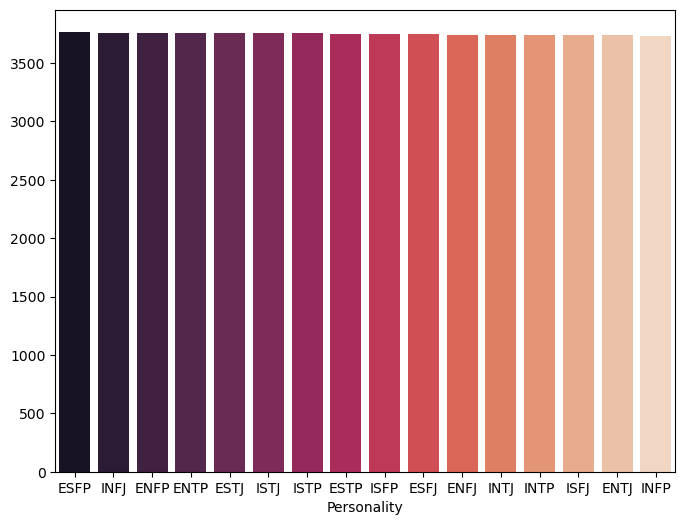

In [ ]:
Personality_counts = df["Personality"].value_counts()
plt.figure(figsize = (8,6))

ax = sns.barplot(
    x = Personality_counts.index ,
    y = Personality_counts.values , 
    palette = "rocket"
)


**Graph Insights:**
All values in the target almost has the same values 